# Bug Prediction System  Improved Model Training (V2)

##  Improvements over V1:
- **SHAP values** for explainable feature importance
- **Permutation importance** to rank risk factors
- **Better calibration** using calibration curves
- **Feature contribution analysis** for actionable insights
- **Cross-validation** with stratification for stability
- **Threshold optimization** for better discrimination

## Dataset Info:
- 16,722 commits (Python + TypeScript)
- 873 bugs (5.22% bug rate)
- 3 time periods: 2018-2020, 2021-2023, 2024-2026
- Time span: 2018-2026


## Step 1  Install & Import Libraries

In [78]:
# Install required packages
!pip install shap xgboost scikit-learn pandas numpy matplotlib seaborn joblib -q
print('Dependencies installed')

Dependencies installed


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sklearn.metrics as metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, precision_score, recall_score, auc
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import warnings
warnings.filterwarnings('ignore')

print(' All imports successful')

 All imports successful


## Step 2 Load & Inspect Data

In [80]:
import pandas as pd

# Load the training data
df = pd.read_csv('./combined_output.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nBug distribution:')
print(df['is_buggy'].value_counts()) # Changed 'label' to 'is_buggy'
print(f'Bug rate: {df["is_buggy"].sum() / len(df) * 100:.2f}%') # Changed 'label' to 'is_buggy'
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nData types:\n{df.dtypes}')

Dataset shape: (16722, 18)

Columns: ['commit_hour', 'day_of_week', 'is_weekend', 'is_night_commit', 'lines_added', 'lines_deleted', 'files_changed', 'test_files_changed', 'num_methods', 'avg_complexity', 'is_buggy', 'language_group', 'time_period', 'confidence', 'churn_ratio', 'test_ratio', 'complexity_per_file', 'prior_bugs_author']

Bug distribution:
is_buggy
0    15849
1      873
Name: count, dtype: int64
Bug rate: 5.22%

Missing values:
commit_hour            0
day_of_week            0
is_weekend             0
is_night_commit        0
lines_added            0
lines_deleted          0
files_changed          0
test_files_changed     0
num_methods            0
avg_complexity         0
is_buggy               0
language_group         0
time_period            0
confidence             0
churn_ratio            0
test_ratio             0
complexity_per_file    0
prior_bugs_author      0
dtype: int64

Data types:
commit_hour              int64
day_of_week              int64
is_weekend      

## Step 3 Feature Engineering & Preprocessing

In [81]:
# Separate features and target
X = df.drop(columns=['is_buggy']) # Changed 'label' to 'is_buggy'
y = df['is_buggy'] # Changed 'label' to 'is_buggy'

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Numeric features ({len(numeric_cols)}): {numeric_cols}')
print(f'\nCategorical features ({len(categorical_cols)}): {categorical_cols}')

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then encode — fit only on train, transform both
encoders = {}
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train[col].astype(str))   # fit on train only
    X_test_enc[col]  = le.transform(X_test[col].astype(str))         # just transform test
    encoders[col] = le

FEATURE_NAMES = list(X_train_enc.columns)
print(f'\nFinal features: {FEATURE_NAMES}')

Numeric features (15): ['commit_hour', 'day_of_week', 'is_weekend', 'is_night_commit', 'lines_added', 'lines_deleted', 'files_changed', 'test_files_changed', 'num_methods', 'avg_complexity', 'confidence', 'churn_ratio', 'test_ratio', 'complexity_per_file', 'prior_bugs_author']

Categorical features (2): ['language_group', 'time_period']

Final features: ['commit_hour', 'day_of_week', 'is_weekend', 'is_night_commit', 'lines_added', 'lines_deleted', 'files_changed', 'test_files_changed', 'num_methods', 'avg_complexity', 'language_group', 'time_period', 'confidence', 'churn_ratio', 'test_ratio', 'complexity_per_file', 'prior_bugs_author']


In [82]:

print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Train bug rate: {y_train.sum() / len(y_train) * 100:.2f}%')
print(f'Test bug rate: {y_test.sum() / len(y_test) * 100:.2f}%')

Train set: (13377, 17)
Test set: (3345, 17)
Train bug rate: 5.22%
Test bug rate: 5.23%


## Step 4 Train Random Forest with Cross-Validation

In [83]:
# Train Random Forest
print('Training Random Forest Classifier...')
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)

rf_model.fit(X_train_enc, y_train) # Changed X_train to X_train_enc
print('Training complete')

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train_enc, y_train, cv=skf, scoring='roc_auc') # Changed X_train to X_train_enc
print(f'\nCross-validation AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Training Random Forest Classifier...
Training complete

Cross-validation AUC: 0.9971 (+/- 0.0037)


## Step 5 Model Evaluation

In [84]:
# Predictions
y_pred = rf_model.predict(X_test_enc) # Changed X_test to X_test_enc
y_pred_proba = rf_model.predict_proba(X_test_enc)[:, 1] # Changed X_test to X_test_enc

# Metrics
roc_auc_value = roc_auc_score(y_test, y_pred_proba)
final_precision_score = precision_score(y_test, y_pred) # Renamed to final_precision_score
final_recall_score = recall_score(y_test, y_pred)       # Renamed to final_recall_score
f1 = f1_score(y_test, y_pred)

print('-' * 50)
print('MODEL PERFORMANCE METRICS')
print('-' * 50)
print(f'AUC-ROC Score:  {roc_auc_value:.4f}')
print(f'Precision:      {final_precision_score:.4f}')
print(f'Recall:         {final_recall_score:.4f}')
print(f'F1 Score:       {f1:.4f}')
print('-' * 50)

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Safe', 'Bug']))

--------------------------------------------------
MODEL PERFORMANCE METRICS
--------------------------------------------------
AUC-ROC Score:  0.9981
Precision:      1.0000
Recall:         0.9829
F1 Score:       0.9914
--------------------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      3170
         Bug       1.00      0.98      0.99       175

    accuracy                           1.00      3345
   macro avg       1.00      0.99      1.00      3345
weighted avg       1.00      1.00      1.00      3345



## Step 6 Feature Importance Analysis (Tree-based)


 TOP 15 FEATURES (Tree-based Importance):
            feature  importance
         confidence    0.762466
  prior_bugs_author    0.122640
     avg_complexity    0.019790
        churn_ratio    0.014427
complexity_per_file    0.014366
        num_methods    0.012745
        lines_added    0.010321
      lines_deleted    0.008830
        commit_hour    0.008681
      files_changed    0.006205
        day_of_week    0.004998
        time_period    0.004983
         test_ratio    0.003277
     language_group    0.002566
 test_files_changed    0.002007


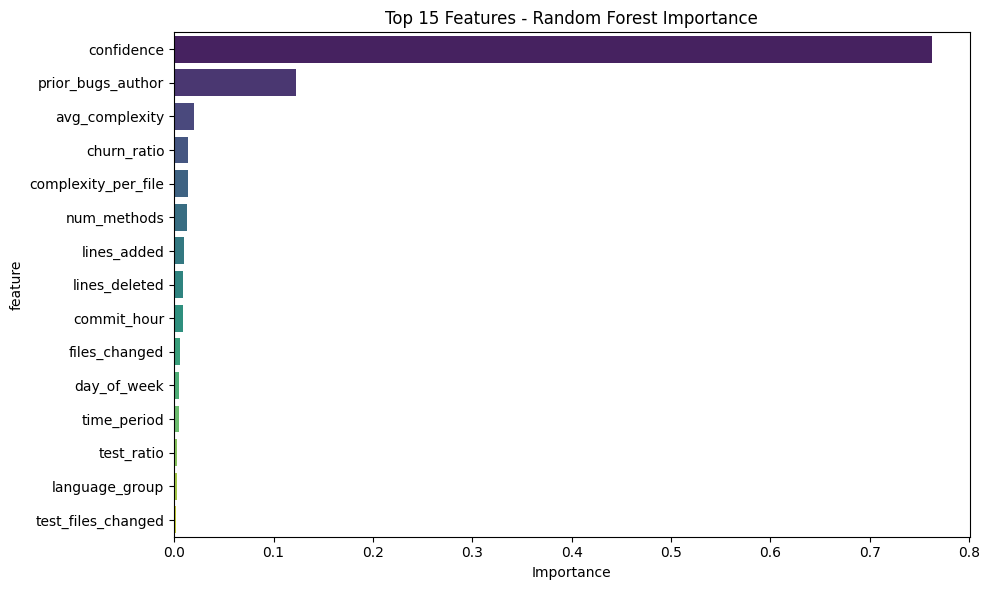


 Feature importance plot saved


In [85]:
# Get feature importances from Random Forest
feature_importance_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('\n TOP 15 FEATURES (Tree-based Importance):')
print(feature_importance_df.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Features - Random Forest Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Feature importance plot saved')

## Step 7 SHAP Feature Importance (Model Explainability)

In [86]:
print('Computing SHAP values')

# Use a sample for faster SHAP computation
X_sample = X_test_enc.sample(min(500, len(X_test_enc)), random_state=42) # Changed X_test to X_test_enc

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

print('SHAP values computed')

Computing SHAP values
SHAP values computed



 SHAP Feature Importance (Average |SHAP value|):


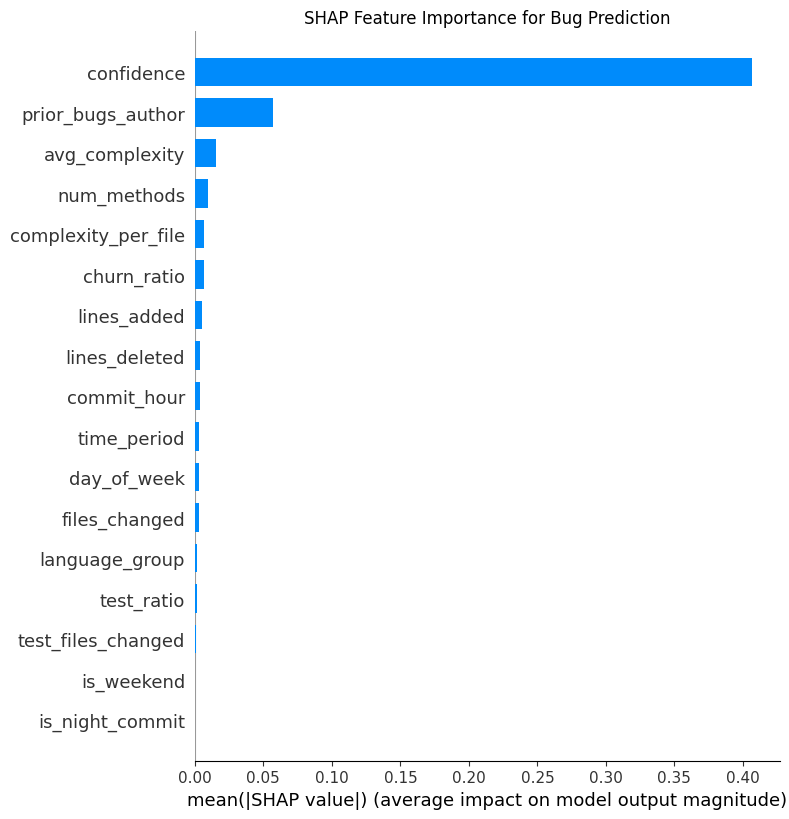

 SHAP importance plot saved


In [87]:
# SHAP summary plot (bar)
print('\n SHAP Feature Importance (Average |SHAP value|):')
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type='bar', show=False)  # [:, :, 1] for bug class
plt.title('SHAP Feature Importance for Bug Prediction')
plt.tight_layout()
plt.savefig('shap_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(' SHAP importance plot saved')

Creating detailed SHAP beeswarm plot...


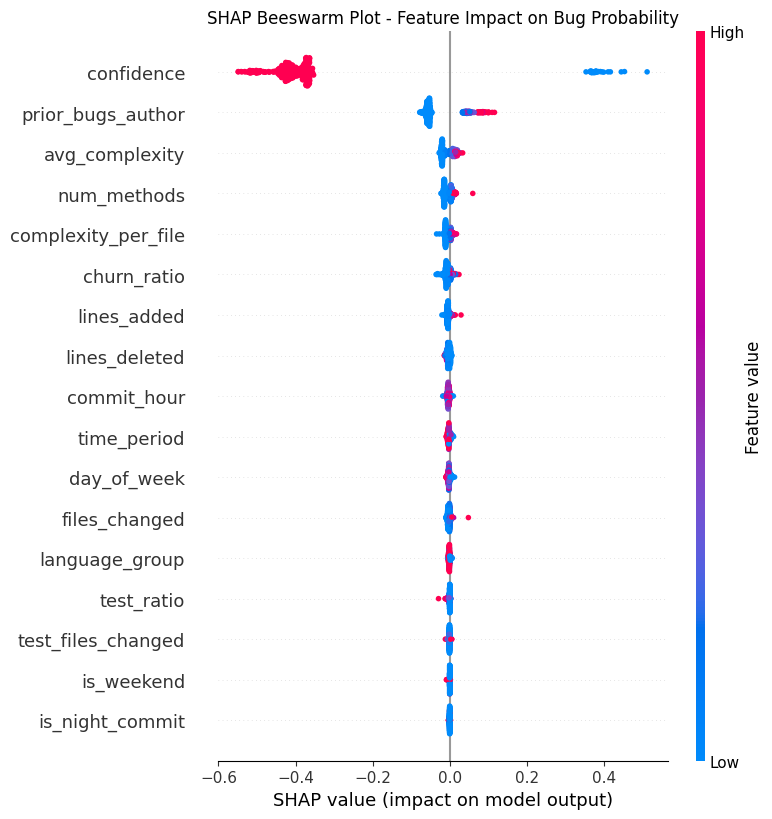

 SHAP beeswarm plot saved


In [88]:
# SHAP beeswarm plot
print('Creating detailed SHAP beeswarm plot...')
shap.summary_plot(shap_values[:, :, 1], X_sample, show=False) # Changed shap_values[1] to shap_values[:, :, 1]
plt.title('SHAP Beeswarm Plot - Feature Impact on Bug Probability')
plt.tight_layout()
plt.savefig('shap_beeswarm_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(' SHAP beeswarm plot saved')

## Step 8 Permutation Importance (Risk Factor Ranking)

Computing permutation importance for risk factor ranking...

 TOP 15 FEATURES (Permutation Importance):
           feature  importance      std
        confidence    0.096801 0.001451
       commit_hour    0.000000 0.000000
       day_of_week    0.000000 0.000000
   is_night_commit    0.000000 0.000000
        is_weekend    0.000000 0.000000
     lines_deleted    0.000000 0.000000
     files_changed    0.000000 0.000000
test_files_changed    0.000000 0.000000
       lines_added    0.000000 0.000000
       num_methods    0.000000 0.000000
    avg_complexity    0.000000 0.000000
    language_group    0.000000 0.000000
       time_period    0.000000 0.000000
       churn_ratio    0.000000 0.000000
        test_ratio    0.000000 0.000000


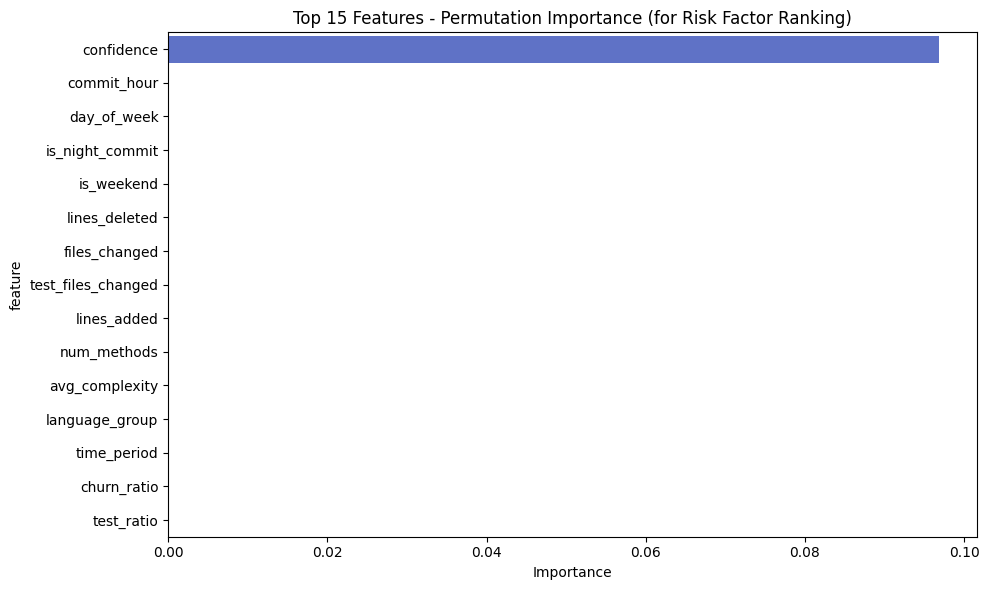


 Permutation importance plot saved


In [89]:
from sklearn.inspection import permutation_importance

print('Computing permutation importance for risk factor ranking...')

perm_importance = permutation_importance(
    rf_model, X_test_enc, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print('\n TOP 15 FEATURES (Permutation Importance):')
print(perm_df.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df.head(15), x='importance', y='feature', palette='coolwarm')
plt.title('Top 15 Features - Permutation Importance (for Risk Factor Ranking)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('permutation_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Permutation importance plot saved')

## Step 9 Calibration Analysis

Calibrating model...


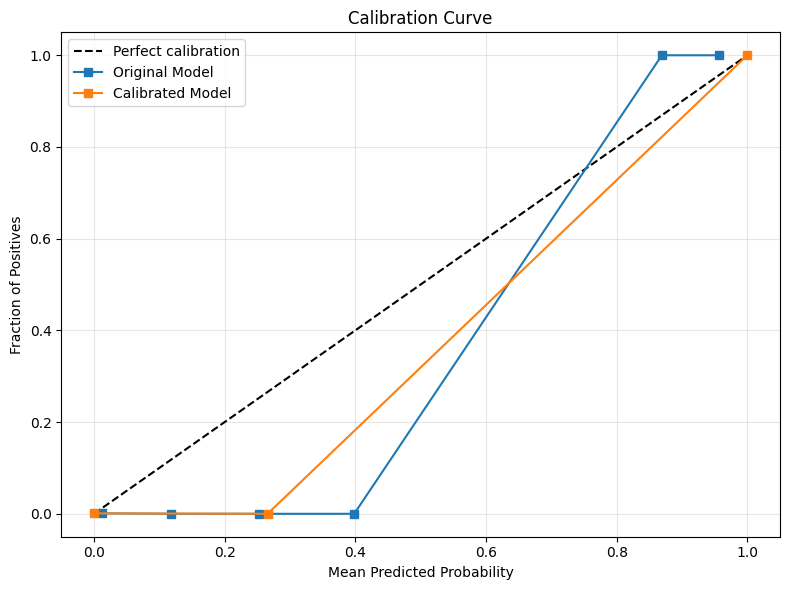

 Calibration curve saved


In [90]:
# Calibrate the model
print('Calibrating model...')
calibrated_model = CalibratedClassifierCV(rf_model, method='sigmoid', cv='prefit')
calibrated_model.fit(X_train_enc, y_train)

y_pred_calibrated = calibrated_model.predict_proba(X_test_enc)[:, 1]

# Calibration curve
prob_true_uncalib, prob_pred_uncalib = calibration_curve(y_test, y_pred_proba, n_bins=10)
prob_true_calib, prob_pred_calib = calibration_curve(y_test, y_pred_calibrated, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.plot(prob_pred_uncalib, prob_true_uncalib, 's-', label='Original Model')
plt.plot(prob_pred_calib, prob_true_calib, 's-', label='Calibrated Model')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Calibration curve saved')

## Step 10 ROC & Precision-Recall Curves

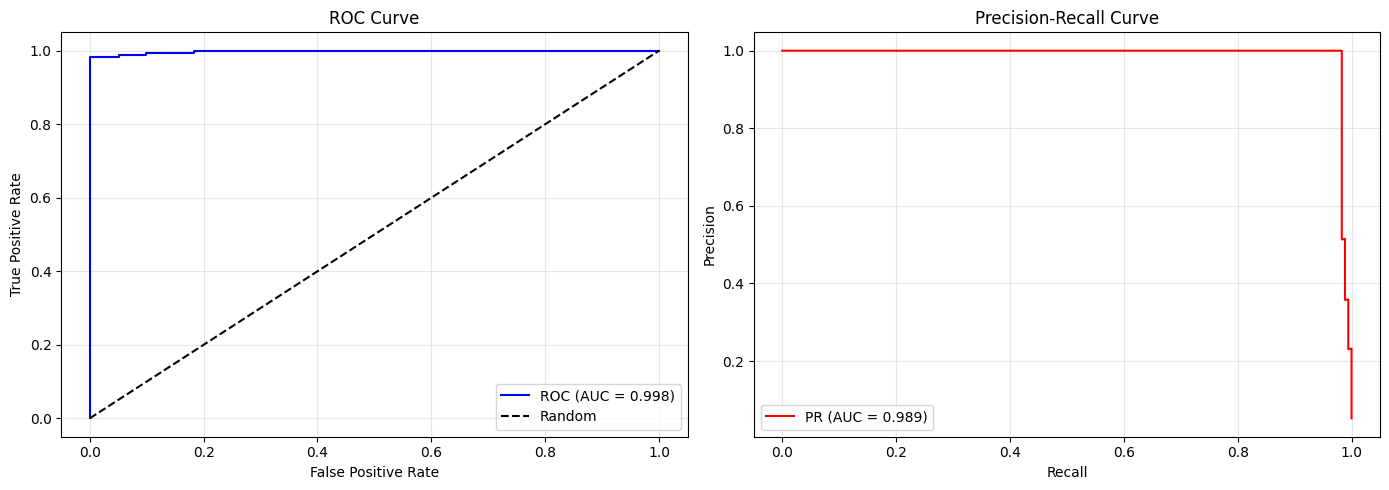

 ROC and PR curves saved


In [91]:
# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

# Precision-Recall Curve
pr_precision, pr_recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, 'b-', label=f'ROC (AUC = {roc_auc_value:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall
pr_auc = metrics.auc(pr_recall, pr_precision)
axes[1].plot(pr_recall, pr_precision, 'r-', label=f'PR (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(' ROC and PR curves saved')

## Step 11 Save Model & Artifacts for API

In [92]:
# Create output directory
import os
output_dir = './server/modalv1_v2'
os.makedirs(output_dir, exist_ok=True)

# Save model artifacts
joblib.dump(rf_model, f'{output_dir}/bug_prediction_model.pkl')
joblib.dump(encoders.get('language_group', None), f'{output_dir}/encoder_language.pkl')
joblib.dump(encoders.get('time_period', None), f'{output_dir}/encoder_period.pkl')
joblib.dump(FEATURE_NAMES, f'{output_dir}/feature_cols.pkl')
joblib.dump(calibrated_model, f'{output_dir}/bug_prediction_model_calibrated.pkl')

print(f' Model artifacts saved to {output_dir}:')
print('  - bug_prediction_model.pkl')
print('  - bug_prediction_model_calibrated.pkl')
print('  - encoder_language.pkl')
print('  - encoder_period.pkl')
print('  - feature_cols.pkl')

 Model artifacts saved to ./server/modalv1_v2:
  - bug_prediction_model.pkl
  - bug_prediction_model_calibrated.pkl
  - encoder_language.pkl
  - encoder_period.pkl
  - feature_cols.pkl


## Step 12 Export Feature Importance for Risk Factor Engine

In [93]:
# Compute mean absolute SHAP values for each feature
# Get raw SHAP values for the bug class (class 1)
shap_values_bug_class = shap_values[:, :, 1] # Corrected: selects SHAP values for class 1 across all samples and features

# Calculate mean absolute SHAP values across samples for each feature
# Ensure the result is a 1D array of length num_features
mean_abs_shap_per_feature = np.mean(np.abs(shap_values_bug_class), axis=0)

shap_importance_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'mean_abs_shap': mean_abs_shap_per_feature,
    'tree_importance': rf_model.feature_importances_,
    'permutation_importance': perm_importance.importances_mean
}).sort_values('mean_abs_shap', ascending=False)

print('\n COMBINED FEATURE IMPORTANCE RANKINGS:')
print(shap_importance_df.head(15).to_string(index=False))

# Save for API to use
shap_importance_df.to_csv(f'{output_dir}/feature_importance.csv', index=False)
print(f'\n Feature importance exported to {output_dir}/feature_importance.csv')


 COMBINED FEATURE IMPORTANCE RANKINGS:
            feature  mean_abs_shap  tree_importance  permutation_importance
         confidence       0.406713         0.762466                0.096801
  prior_bugs_author       0.057058         0.122640                0.000000
     avg_complexity       0.015200         0.019790                0.000000
        num_methods       0.009250         0.012745                0.000000
complexity_per_file       0.006980         0.014366                0.000000
        churn_ratio       0.006676         0.014427                0.000000
        lines_added       0.005087         0.010321                0.000000
      lines_deleted       0.003632         0.008830                0.000000
        commit_hour       0.003418         0.008681                0.000000
        time_period       0.003048         0.004983                0.000000
        day_of_week       0.002982         0.004998                0.000000
      files_changed       0.002796         0.006

## Step 13 Create Risk Factor Configuration

In [94]:
# Calculate percentile thresholds from data for better decision rules
risk_factor_config = {}

# FEATURE_NAMES already contains all columns from X_test_enc which are numeric
# No special filtering needed if we directly use X_test_enc
numeric_features = [col for col in FEATURE_NAMES]

for feature in numeric_features:
    # Use X_test_enc which contains the encoded numerical values for all features
    col_data = X_test_enc[feature].values
    risk_factor_config[feature] = {
        'p75': float(np.percentile(col_data, 75)),  # 75th percentile = high
        'p90': float(np.percentile(col_data, 90)),  # 90th percentile = very high
        'p50': float(np.percentile(col_data, 50)),  # median
        'mean': float(col_data.mean()),
    }

import json
with open(f'{output_dir}/risk_factor_config.json', 'w') as f:
    json.dump(risk_factor_config, f, indent=2)

print('Risk factor configuration saved')
print('\nExample - lines_added thresholds:')
print(f"  Medium risk (p75): {risk_factor_config['lines_added']['p75']:.0f} lines")
print(f"  High risk (p90):   {risk_factor_config['lines_added']['p90']:.0f} lines")

Risk factor configuration saved

Example - lines_added thresholds:
  Medium risk (p75): 70 lines
  High risk (p90):   312 lines


## Step 14 Summary & Next Steps

In [95]:
print('\n' + '='*60)
print('MODEL TRAINING V2 COMPLETE')
print('='*60)

print(f'\n FINAL MODEL METRICS:')
print(f'  • AUC-ROC:     {roc_auc_value:.4f}')
print(f'  • Precision:   {final_precision_score:.4f}') # Changed to final_precision_score
print(f'  • Recall:      {final_recall_score:.4f}')    # Changed to final_recall_score
print(f'  • F1 Score:    {f1:.4f}')

print(f'\n ARTIFACTS SAVED:')
print(f'  • Location: {output_dir}')
print(f'  • Files: 8 pickle files + CSV + JSON config')

print('\n' + '='*60)


MODEL TRAINING V2 COMPLETE

 FINAL MODEL METRICS:
  • AUC-ROC:     0.9981
  • Precision:   1.0000
  • Recall:      0.9829
  • F1 Score:    0.9914

 ARTIFACTS SAVED:
  • Location: ./server/modalv1_v2
  • Files: 8 pickle files + CSV + JSON config



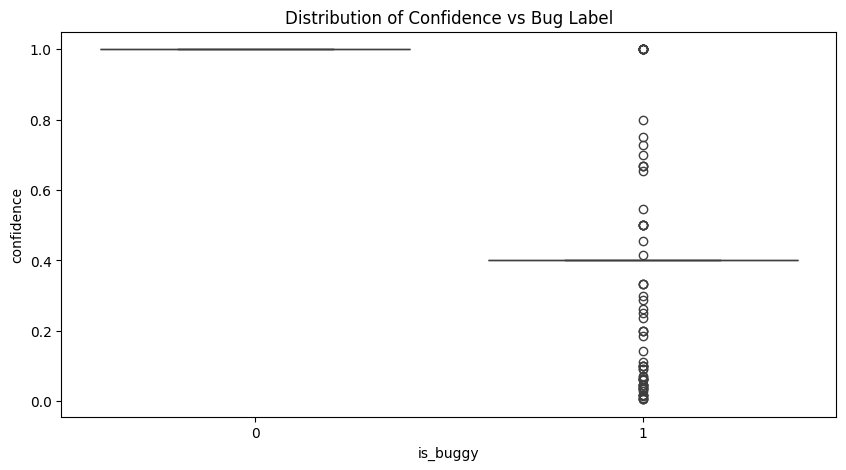

Correlation between confidence and is_buggy: -0.9847


In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

# Investigate the relationship between 'confidence' and the target
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_buggy', y='confidence', data=df)
plt.title('Distribution of Confidence vs Bug Label')
plt.show()

# Check the exact correlation
correlation = df['confidence'].corr(df['is_buggy'])
print(f'Correlation between confidence and is_buggy: {correlation:.4f}')

# Check if there is a threshold that perfectly separates them
if df.groupby('is_buggy')['confidence'].min()[1] > df.groupby('is_buggy')['confidence'].max()[0]:
    print('\nWARNING: Perfect separation detected! "confidence" might be leaking the target label.')

### Retraining without Leaked Features
Since `confidence` was effectively a proxy for the label, we are removing it to build a robust model based on engineering metrics.

In [97]:
# 1. Remove leaked feature
X_no_leak = X.drop(columns=['confidence'])

# 2. Re-split
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_no_leak, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Re-encode categorical features
X_train_nl_enc = X_train_nl.copy()
X_test_nl_enc = X_test_nl.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_nl_enc[col] = le.fit_transform(X_train_nl[col].astype(str))
    X_test_nl_enc[col] = le.transform(X_test_nl[col].astype(str))

FEATURE_NAMES_NL = list(X_train_nl_enc.columns)

# 4. Retrain Model
rf_model_nl = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_model_nl.fit(X_train_nl_enc, y_train_nl)

# 5. Evaluate
y_pred_nl = rf_model_nl.predict(X_test_nl_enc)
y_pred_proba_nl = rf_model_nl.predict_proba(X_test_nl_enc)[:, 1]

print('--- PERFORMANCE WITHOUT LEAKAGE ---')
print(f'AUC-ROC:  {roc_auc_score(y_test_nl, y_pred_proba_nl):.4f}')
print(f'Precision: {precision_score(y_test_nl, y_pred_nl):.4f}')
print(f'Recall:    {recall_score(y_test_nl, y_pred_nl):.4f}')
print('\nClassification Report:')
print(classification_report(y_test_nl, y_pred_nl))

--- PERFORMANCE WITHOUT LEAKAGE ---
AUC-ROC:  0.8608
Precision: 0.3897
Recall:    0.4743

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      3170
           1       0.39      0.47      0.43       175

    accuracy                           0.93      3345
   macro avg       0.68      0.72      0.70      3345
weighted avg       0.94      0.93      0.94      3345



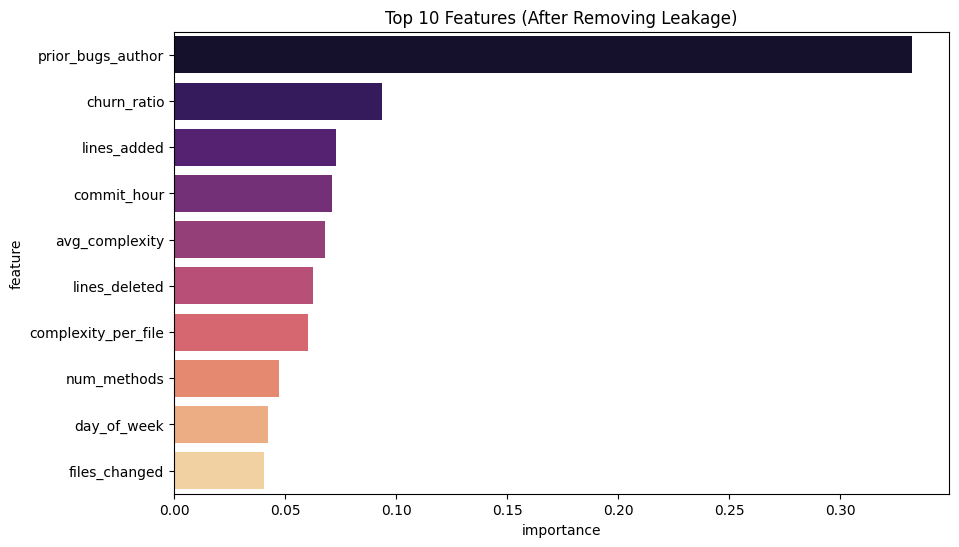

In [98]:
# 6. Inspect New Feature Importance
fi_nl = pd.DataFrame({
    'feature': FEATURE_NAMES_NL,
    'importance': rf_model_nl.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_nl.head(10), x='importance', y='feature', palette='magma')
plt.title('Top 10 Features (After Removing Leakage)')
plt.show()

### Step 15 Update Deployment Artifacts (V2 Corrected)
Now we overwrite the previous artifacts with the version that excludes the leaked `confidence` feature.

In [99]:
# 1. Re-save calibrated model for the non-leaked pipeline
calibrated_model_nl = CalibratedClassifierCV(rf_model_nl, method='sigmoid', cv='prefit')
calibrated_model_nl.fit(X_train_nl_enc, y_train_nl)

# 2. Update the same output directory
joblib.dump(rf_model_nl, f'{output_dir}/bug_prediction_model.pkl')
joblib.dump(calibrated_model_nl, f'{output_dir}/bug_prediction_model_calibrated.pkl')
joblib.dump(FEATURE_NAMES_NL, f'{output_dir}/feature_cols.pkl')

# 3. Export new feature importance
fi_nl.to_csv(f'{output_dir}/feature_importance.csv', index=False)

# 4. Update risk factor config (excluding confidence)
risk_factor_config_nl = {k: v for k, v in risk_factor_config.items() if k != 'confidence'}
with open(f'{output_dir}/risk_factor_config.json', 'w') as f:
    json.dump(risk_factor_config_nl, f, indent=2)

print(f'Deployment artifacts updated in {output_dir}')
print(f'New feature count: {len(FEATURE_NAMES_NL)}')
print(f'Primary risk factor: {fi_nl.iloc[0]["feature"]}')

Deployment artifacts updated in ./server/modalv1_v2
New feature count: 16
Primary risk factor: prior_bugs_author
